In [10]:
import duckdb
import pandas as pd
import sqlite3
import numpy as np
import time
import pyarrow.csv as pv
import pyarrow.parquet as pq
import pyarrow as pa
import statistics
import matplotlib.pyplot as plt

## Part 1: Preparing the data into different formats

In [ ]:
accepted_file = 'accepted_fully_cleaned.csv'

# Your code here: converting the given CSV file into Parquet format ("accepted.parquet") and .db format (accepted.db)
# For .db, create a single table named "loan_table".

# -----------------------------
# EXTREME ROBUST PARSER SETTINGS
# -----------------------------
convert_options = pv.ConvertOptions(
    column_types={},  # disable inference
    strings_can_be_null=True
)

parse_options = pv.ParseOptions(
    delimiter=",",
    ignore_empty_lines=True
)

read_options = pv.ReadOptions(
    block_size=25 * 1024 * 1024  # smaller blocks = safer parsing
)

reader = pv.open_csv(
    accepted_file,
    read_options=read_options,
    parse_options=parse_options,
    convert_options=convert_options
)

# -----------------------------
# OUTPUTS
# -----------------------------
parquet_writer = None
conn = sqlite3.connect("accepted.db")
first_chunk = True

# -----------------------------
# STREAM LOOP WITH SAFETY
# -----------------------------
while True:
    try:
        batch = reader.read_next_batch()
    except StopIteration:
        break
    except Exception:
        # skip corrupted batch instead of crashing
        continue

    table = pa.Table.from_batches([batch])

    # ---- PARQUET ----
    if parquet_writer is None:
        parquet_writer = pq.ParquetWriter(
            "accepted.parquet",
            table.schema
        )

    parquet_writer.write_table(table)

    # ---- SQLITE ----
    df = table.to_pandas()

    df.to_sql(
        "loan_table",
        conn,
        if_exists="replace" if first_chunk else "append",
        index=False
    )

    first_chunk = False

# cleanup
if parquet_writer:
    parquet_writer.close()

conn.close()

print("DONE (robust mode, skipped bad rows if any)")

DONE (robust mode, skipped bad rows if any)


## Part 2 Section 1: Parquet

In [16]:
# Your code starts here: read in Parquet with Duckdb. Run each query 10 times, save the median and standard deviation

def time_query(func, n=10):
    times = []

    for _ in range(n):
        start = time.time()
        func()
        end = time.time()
        times.append(end - start)

    return {
        "median": statistics.median(times),
        "std": statistics.stdev(times)
    }

duck = duckdb.connect()
PARQUET_FILE = "accepted.parquet"


def q1_parquet():
    duck.execute(f"""
        SELECT
            addr_state,
            loan_status,
            purpose,
            emp_title,
            AVG(loan_amnt),
            SUM(loan_amnt),
            MAX(loan_amnt),
            MIN(loan_amnt),
            AVG(annual_inc),
            AVG(dti)
        FROM read_parquet('{PARQUET_FILE}')
        GROUP BY 1,2,3,4
    """).fetchall()


def q2_parquet():
    duck.execute(f"""
        SELECT *
        FROM read_parquet('{PARQUET_FILE}')
        WHERE id IN ('68426831', '68476807')
    """).fetchall()

def q3_parquet():
    duck.execute(f"""
        SELECT id
        FROM read_parquet('{PARQUET_FILE}')
        ORDER BY id ASC
    """).fetchall()


def q4_parquet():
    duck.execute(f"""
        SELECT id
        FROM read_parquet('{PARQUET_FILE}')
        WHERE emp_title IS NOT NULL
        AND LOWER(emp_title) LIKE '%engineer%'
        OR LOWER(emp_title) LIKE '%developer%'
        OR LOWER(emp_title) LIKE '%manager%'
        OR LOWER(emp_title) LIKE '%scientist%'
        OR LOWER(emp_title) LIKE '%banker%'
        OR LOWER(emp_title) LIKE '%accountant%'
        OR LOWER(emp_title) LIKE '%auditor%'
        OR LOWER(emp_title) LIKE '%researcher%'
        ORDER BY id ASC
    """).fetchall()

def q5_parquet():
    duck.execute(f"""
        WITH sample_ids AS (
            SELECT id
            FROM read_parquet('{PARQUET_FILE}')
            WHERE loan_amnt BETWEEN 10000 AND 10100
            AND dti BETWEEN 10 AND 11
            AND addr_state IN ('CA','NY','TX')
            LIMIT 50
        )
        SELECT *
        FROM read_parquet('{PARQUET_FILE}')
        WHERE id IN (SELECT id FROM sample_ids)
        AND revol_bal < 5000
        AND term = ' 36 months'
        AND verification_status != 'Verified'
        AND grade IN ('A','B','C')
        AND purpose IN ('debt_consolidation','credit_card','home_improvement')
        AND int_rate > 10
        ORDER BY issue_d DESC
        LIMIT 50
    """).fetchall()



results = {}

results["q1_parquet"] = time_query(q1_parquet)
results["q2_parquet"] = time_query(q2_parquet)
results["q3_parquet"] = time_query(q3_parquet)
results["q4_parquet"] = time_query(q4_parquet)
results["q5_parquet"] = time_query(q5_parquet)

print(results)

{'q1_parquet': {'median': 0.5033304691314697, 'std': 0.053452398614103884}, 'q2_parquet': {'median': 0.037322044372558594, 'std': 0.004337327680203187}, 'q3_parquet': {'median': 0.07544076442718506, 'std': 0.00783641846755414}, 'q4_parquet': {'median': 0.05140960216522217, 'std': 0.007163721900354193}, 'q5_parquet': {'median': 0.05496644973754883, 'std': 0.05689521173073904}}


## Part 2 Section 2: SQLite

In [17]:
# Your code starts here: read in .db with SQLite. Run each query 10 times, save the median and standard deviation

conn = sqlite3.connect("accepted.db")

def q1_sqlite():
    conn.execute("""
        SELECT
            addr_state,
            loan_status,
            purpose,
            emp_title,
            AVG(loan_amnt),
            SUM(loan_amnt),
            MAX(loan_amnt),
            MIN(loan_amnt),
            AVG(annual_inc),
            AVG(dti)
        FROM loan_table
        GROUP BY addr_state, loan_status, purpose, emp_title
    """).fetchall()



def q2_sqlite():
    conn.execute("""
        SELECT *
        FROM loan_table
        WHERE id IN ('68426831', '68476807')
    """).fetchall()


def q3_sqlite():
    conn.execute("""
        SELECT id
        FROM loan_table
        ORDER BY id ASC
    """).fetchall()


def q4_sqlite():
    conn.execute("""
        SELECT id
        FROM loan_table
        WHERE emp_title IS NOT NULL
        AND (
            LOWER(emp_title) LIKE '%engineer%' OR
            LOWER(emp_title) LIKE '%developer%' OR
            LOWER(emp_title) LIKE '%manager%' OR
            LOWER(emp_title) LIKE '%scientist%' OR
            LOWER(emp_title) LIKE '%banker%' OR
            LOWER(emp_title) LIKE '%accountant%' OR
            LOWER(emp_title) LIKE '%auditor%' OR
            LOWER(emp_title) LIKE '%researcher%'
        )
        ORDER BY id ASC
    """).fetchall()



def q5_sqlite():
    conn.execute("""
        WITH sample_ids AS (
            SELECT id
            FROM loan_table
            WHERE loan_amnt BETWEEN 10000 AND 10100
            AND dti BETWEEN 10 AND 11
            AND addr_state IN ('CA','NY','TX')
            LIMIT 50
        )
        SELECT *
        FROM loan_table
        WHERE id IN (SELECT id FROM sample_ids)
        AND revol_bal < 5000
        AND term = ' 36 months'
        AND verification_status != 'Verified'
        AND grade IN ('A','B','C')
        AND purpose IN ('debt_consolidation','credit_card','home_improvement')
        AND int_rate > 10
        ORDER BY issue_d DESC
        LIMIT 50
    """).fetchall()

results["q1_sqlite"] = time_query(q1_sqlite)
results["q2_sqlite"] = time_query(q2_sqlite)
results["q3_sqlite"] = time_query(q3_sqlite)
results["q4_sqlite"] = time_query(q4_sqlite)
results["q5_sqlite"] = time_query(q5_sqlite)
print(results)


{'q1_parquet': {'median': 0.5033304691314697, 'std': 0.053452398614103884}, 'q2_parquet': {'median': 0.037322044372558594, 'std': 0.004337327680203187}, 'q3_parquet': {'median': 0.07544076442718506, 'std': 0.00783641846755414}, 'q4_parquet': {'median': 0.05140960216522217, 'std': 0.007163721900354193}, 'q5_parquet': {'median': 0.05496644973754883, 'std': 0.05689521173073904}, 'q1_sqlite': {'median': 1.3812309503555298, 'std': 0.1164041951909567}, 'q2_sqlite': {'median': 0.09037899971008301, 'std': 0.009605516961820795}, 'q3_sqlite': {'median': 0.31982362270355225, 'std': 0.034487492312730864}, 'q4_sqlite': {'median': 0.5329387187957764, 'std': 0.03267857365994557}, 'q5_sqlite': {'median': 0.0869823694229126, 'std': 0.008970497232523553}}


## Part 2 Section 3: Answering Q1 to Q5

For each question (query), 1) give your answer to the multiple choice question 2) create a bar graph using Matplotlib for the median time taken for both formats, with standard errors, and 3) write 1 to 2 sentences explaining your answer to the multiple choice question.

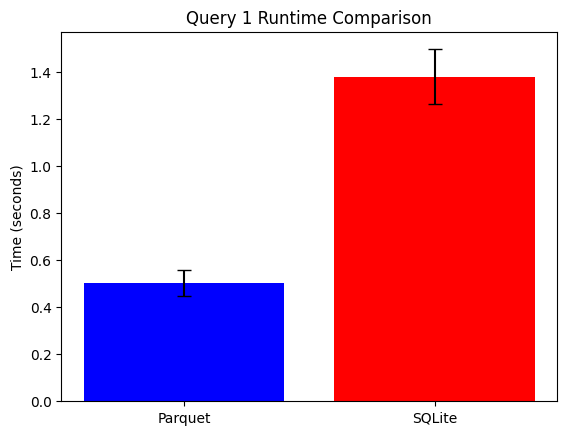

In [20]:
labels = ["Parquet", "SQLite"]

medians = [
    results["q1_parquet"]["median"],
    results["q1_sqlite"]["median"]
]

stds = [
    results["q1_parquet"]["std"],
    results["q1_sqlite"]["std"]
]

plt.bar(labels, medians, yerr=stds, color=["blue", "red"], capsize=5)
plt.title("Query 1 Runtime Comparison")
plt.ylabel("Time (seconds)")
plt.show()

## Part 3 Section 1: Parquet, SQLite, and Pandas on the large dataset

Repeat the process above for the larger dataset "accepted_large.csv". Query it in Parquet format with Duckdb, in ".db" format with SQLite, and in original format (i.e. CSV) with Pandas. Run each query 10 times, save the median and standard deviation.

In [ ]:
large_file = "accepted_large.csv"

# Your code starts here:

## Part 3 Section 1: Answering Q6 to Q7

In [3]:
# Include your answers here